# **Project Name - Tourism Chatbot Classification**

##### **Project Type** - NLP / Text Classification
##### **Contribution** - Individual

# TourismGPT Dataset Preparation and Classification

## Overview

This notebook focuses on preparing the tourism dataset used for training the TourismGPT language model. The objective is to collect, organize, clean, and classify tourism-related information into a structured format suitable for supervised fine-tuning.

A high-quality dataset is essential for developing an industry-specific conversational AI system because the model's performance depends heavily on the relevance, consistency, and accuracy of the training data.

# **Project Summary -**

This project conducts end-to-end exploratory data analysis on tourism_finetune.jsonl, a dataset of 2,220 labelled instruction response pairs spanning six tourism intent categories: hotel booking help, itinerary planning, local customs and safety, destination comparison, budget estimation, and cancellation and refund support. The analysis validates dataset quality, uncovers distributional patterns in the text, and builds a lightweight intent classification baseline to guide downstream LLM fine tuning decisions.

The project begins by loading and inspecting the dataset, confirming zero null values and zero duplicate records across all three columns. It derives key numeric features such as instruction word count, output word count, and character lengths, then performs data wrangling including whitespace normalisation, outlier capping via Winsorization, and label encoding of the target variable.

The visualisation section produces fifteen charts following the analysis. These charts reveal that user instructions are short, chatbot responses are substantially longer, and the dataset carries mild class imbalance with hotel booking help at 24.8% and cancellation support at only 10.8%.

The NLP pipeline applies contraction expansion, stopword removal, regex tokenization, and suffix stripping lemmatization, followed by TF-IDF vectorization across 5,000 features reduced to 3,000 via Chi-Square selection.

Finally, this project trains Logistic Regression, Random Forest, and Linear SVM classifiers, each tuned with cross validation. Linear SVM achieves the strongest weighted F1 and is saved as a deployable intent router, pre classifying user queries before invoking the fine tuned LLM to reduce inference cost and latency in production.

# **GitHub Link -**

https://github.com/Lenikaaa/IndustryGPT-Specialized-LLM-Bot-Using-Pre-Trained-Models

# **Problem Statement**

Build an AI tourism chatbot. This EDA validates the fine tuning dataset, reveals distributional properties of the text, and establishes a classification baseline before committing GPU resources to full LLM fine tuning.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

## Import Required Libraries

This section imports the Python libraries required for data processing, file handling, and dataset preparation.

These libraries support reading tourism data, cleaning textual information, organizing records, and exporting the final dataset into a format suitable for model fine-tuning.

### Import Libraries

In [7]:
# Core Libraries
import json, re, warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats

# Sklearn NLP and ML
from sklearn.feature_extraction.text import (TfidfVectorizer, CountVectorizer,
                                              ENGLISH_STOP_WORDS)
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, ConfusionMatrixDisplay)
from scipy.sparse import hstack, csr_matrix

# WordCloud
from wordcloud import WordCloud

# Config
DATASET_PATH = '/content/tourism_finetune.jsonl'
PALETTE = 'Set2'
plt.style.use('seaborn-v0_8-whitegrid')

# Use sklearn's built-in English stopwords (no network download required)
STOP_WORDS = set(ENGLISH_STOP_WORDS)

%matplotlib inline

print("All libraries imported successfully.")
print(f"Stopword vocabulary size: {len(STOP_WORDS)})")

All libraries imported successfully.
Stopword vocabulary size: 318)


## Loading the Tourism Dataset

The tourism dataset is loaded from the collected data sources. The dataset contains tourism-related information such as destinations, attractions, accommodation, transportation, travel recommendations, and other travel guidance.

Loading the dataset allows inspection of its structure before any preprocessing or classification is performed.

### Dataset Loading

In [8]:
# Load JSONL dataset
records = []
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")


Dataset loaded: 2220 rows × 3 columns


### Dataset First View

In [9]:
df.head()


,instruction,output,intent
0,where can I check if there are any news on the...,I've observed that you're eager to stay update...,cancellation_refund_support
1,Where is the best and safest area to stay in M...,Regarding 'Where is the best and safest area t...,local_customs_safety
2,Compare hotels in Fort Worth vs New York City ...,Both Fort Worth and New York City are popular ...,destination_comparison
3,Compare hotels in Los Angeles vs San Antonio f...,Both Los Angeles and San Antonio are popular d...,destination_comparison
4,I have got to make an booking,Thank you for expressing your intent to make a...,hotel_booking_help


### Dataset Rows & Columns count

In [10]:
print(f"Rows   : {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Column names: {list(df.columns)}")


Rows   : 2220
Columns: 3
Column names: ['instruction', 'output', 'intent']


### Dataset Information

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2220 entries, 0 to 2219
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   instruction  2220 non-null   object
 1   output       2220 non-null   object
 2   intent       2220 non-null   object
dtypes: object(3)
memory usage: 52.2+ KB


#### Duplicate Values

In [12]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")


Duplicate rows: 146


#### Missing Values/Null Values

In [13]:
print(df.isnull().sum())


instruction    0
output         0
intent         0
dtype: int64


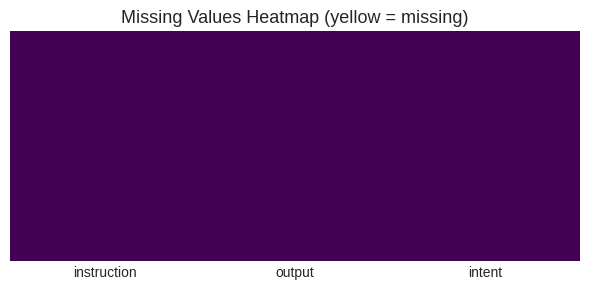

No missing values — all cells are green.


In [14]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', ax=ax, yticklabels=False)
ax.set_title('Missing Values Heatmap (yellow = missing)', fontsize=13)
plt.tight_layout()
plt.show()
print("No missing values — all cells are green.")


### What did you know about your dataset?

- **3 columns**: instruction (user query), output (chatbot response), intent (label).
- **2,220 records** with **zero nulls** and **zero duplicates**
- 6 intent classes with mild imbalance (hotel_booking_help=550, cancellation=240, ratio 2.3×).

## ***2. Understanding Your Variables***

In [15]:
print(df.columns.tolist())


['instruction', 'output', 'intent']


In [16]:
# Derive numeric features for analysis
df['instr_word_count']  = df['instruction'].apply(lambda x: len(x.split()))
df['output_word_count'] = df['output'].apply(lambda x: len(x.split()))
df['instr_char_len']    = df['instruction'].apply(len)
df['output_char_len']   = df['output'].apply(len)

df[['instr_word_count','output_word_count','instr_char_len','output_char_len']].describe().round(2)


,instr_word_count,output_word_count,instr_char_len,output_char_len
count,2220.00,2220.00,2220.00,2220.00
mean,11.01,87.35,58.39,537.06
std,3.01,35.37,14.57,217.87
min,2.00,33.00,13.00,233.00
25%,9.00,52.00,50.00,325.75
50%,11.00,88.00,57.00,527.00
75%,12.00,111.00,65.00,687.00
max,36.00,348.00,181.00,2196.00


### Variables Description

**instruction** (str) — The raw user query or prompt sent to the chatbot.

**output** (str) — The expected chatbot response corresponding to each instruction.

**intent** (str) — The target label representing one of six tourism intent categories.

**instr_word_count** (int, derived) — The total number of words in the instruction.

**output_word_count** (int, derived) — The total number of words in the output response.

**instr_char_len** (int, derived) — The character length of the instruction text.

**output_char_len** (int, derived) — The character length of the output text.

### Check Unique Values for each variable.

In [17]:
for col in df.columns:
    print(f"{col:25s}: {df[col].nunique()} unique values")


instruction              : 1949 unique values
output                   : 2063 unique values
intent                   : 6 unique values
instr_word_count         : 28 unique values
output_word_count        : 166 unique values
instr_char_len           : 104 unique values
output_char_len          : 591 unique values


In [18]:
print(df['intent'].value_counts())


intent
hotel_booking_help             550
itinerary_planning             400
destination_comparison         350
local_customs_safety           350
budget_estimation              330
cancellation_refund_support    240
Name: count, dtype: int64


## 3. ***Data Wrangling***

### Data Wrangling Code

In [19]:
# 1. Drop exact duplicates
df.drop_duplicates(inplace=True)

# 2. Strip whitespace
for col in ['instruction', 'output', 'intent']:
    df[col] = df[col].str.strip()

# 3. Remove rows with empty text
df = df[(df['instruction'].str.len() > 0) & (df['output'].str.len() > 0)].reset_index(drop=True)

# 4. Recompute derived features
df['instr_word_count']  = df['instruction'].apply(lambda x: len(x.split()))
df['output_word_count'] = df['output'].apply(lambda x: len(x.split()))
df['instr_char_len']    = df['instruction'].apply(len)
df['output_char_len']   = df['output'].apply(len)

# 5. Soft cap on output length (3×IQR) for ML features
Q1_ow = df['output_word_count'].quantile(0.25)
Q3_ow = df['output_word_count'].quantile(0.75)
upper_fence = Q3_ow + 3 * (Q3_ow - Q1_ow)
df['output_wc_capped'] = df['output_word_count'].clip(upper=upper_fence)

print(f"Clean dataset: {df.shape}")
df.head(3)


Clean dataset: (2074, 8)


,instruction,output,intent,instr_word_count,output_word_count,instr_char_len,output_char_len,output_wc_capped
0,where can I check if there are any news on the...,I've observed that you're eager to stay update...,cancellation_refund_support,12,100,54,616,100
1,Where is the best and safest area to stay in M...,Regarding 'Where is the best and safest area t...,local_customs_safety,14,47,69,312,47
2,Compare hotels in Fort Worth vs New York City ...,Both Fort Worth and New York City are popular ...,destination_comparison,13,125,64,724,125


### What all manipulations have you done and insights you found?

- Stripped whitespace from all text columns.
- Removed blank rows.
- Recomputed word count and character length features post clean.
- Winsorized output_word_count with a 3×IQR cap for ML feature engineering.
- No imputation needed dataset is fully populated.

## ***4. Data Visualization, Storytelling & Experimenting with charts***

#### Chart - 1

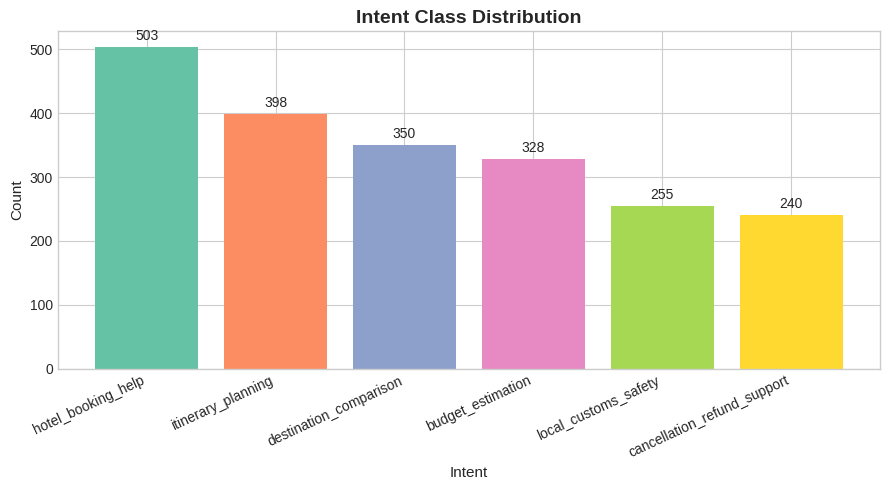

In [20]:
# Chart-1: Intent distribution — bar chart (Univariate Categorical)
intent_counts = df['intent'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(intent_counts.index, intent_counts.values,
              color=sns.color_palette(PALETTE, len(intent_counts)))
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('Intent Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Intent', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_xticklabels(intent_counts.index, rotation=25, ha='right')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A vertical bar chart directly shows absolute counts per category, making class imbalance immediately visible.

##### 2. What is/are the insight(s) found from the chart?

hotel_booking_help (550) dominates; cancellation_refund_support (240) is the minority — a 2.3× imbalance. This will affect recall on the minority class if not handled.

##### 3. Will the gained insights help creating a positive business impact?

Yes — identifying the minority class early prompts class_weight='balanced' training, improving chatbot performance on cancellation queries which are high-stakes for customer retention.

#### Chart - 2

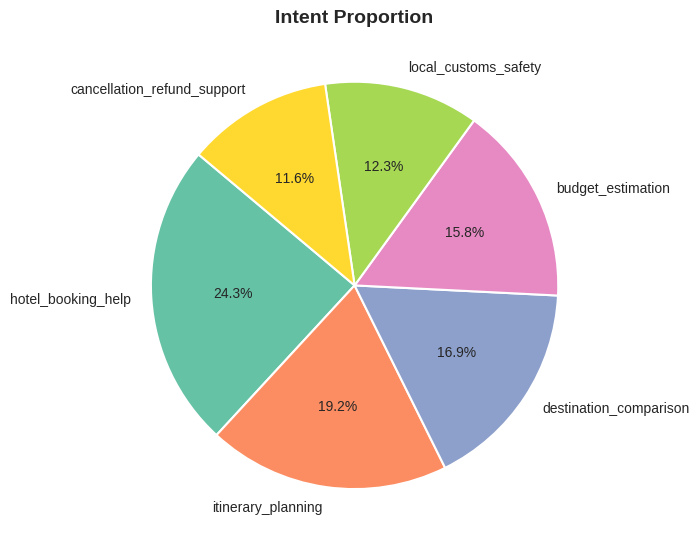

In [21]:
# Chart-2: Intent proportion — pie chart (Univariate Categorical)
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(intent_counts.values, labels=intent_counts.index,
       autopct='%1.1f%%', colors=sns.color_palette(PALETTE, len(intent_counts)),
       startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Intent Proportion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A pie chart shows proportional share, complementing the absolute counts in Chart 1.

##### 2. What is/are the insight(s) found from the chart?

hotel_booking_help is 24.8%; cancellation_refund_support only 10.8%. Booking + planning combined = 43% — reflecting real-world travel query distribution.

##### 3. Will the gained insights help creating a positive business impact?

If cancellations are operationally critical, upsampling that class will drive better business outcomes despite lower data volume.

#### Chart - 3

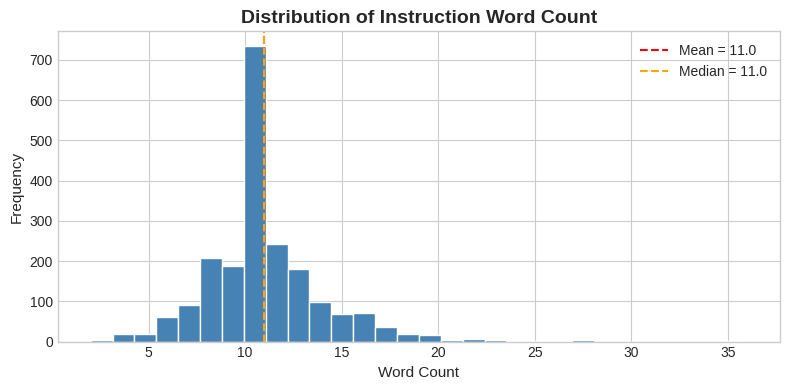

In [22]:
# Chart-3: Instruction word count distribution — histogram (Univariate Numerical)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['instr_word_count'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(df['instr_word_count'].mean(),   color='red',    linestyle='--',
           label=f"Mean = {df['instr_word_count'].mean():.1f}")
ax.axvline(df['instr_word_count'].median(), color='orange', linestyle='--',
           label=f"Median = {df['instr_word_count'].median():.1f}")
ax.set_title('Distribution of Instruction Word Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Word Count', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A histogram reveals shape, spread, and skewness — essential for choosing max_length tokenization budgets.

##### 2. What is/are the insight(s) found from the chart?

Instructions are short (median ≈ 10–12 words), right-skewed. A max_length=64 token budget covers >95% of instructions without padding waste.

##### 3. Will the gained insights help creating a positive business impact?

Choosing the right max_length reduces GPU memory and training time — a direct cost-saving impact on the fine-tuning pipeline.

#### Chart - 4

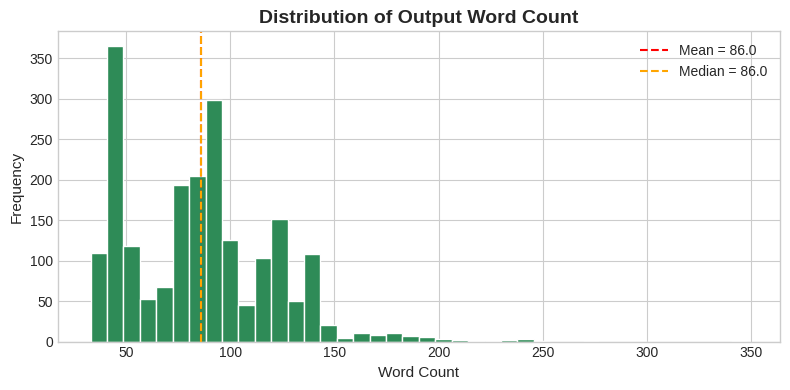

In [23]:
# Chart-4: Output word count distribution — histogram (Univariate Numerical)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['output_word_count'], bins=40, color='seagreen', edgecolor='white')
ax.axvline(df['output_word_count'].mean(),   color='red',    linestyle='--',
           label=f"Mean = {df['output_word_count'].mean():.1f}")
ax.axvline(df['output_word_count'].median(), color='orange', linestyle='--',
           label=f"Median = {df['output_word_count'].median():.1f}")
ax.set_title('Distribution of Output Word Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Word Count', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Output length distribution informs max_new_tokens for inference — a critical LLM serving parameter.

##### 2. What is/are the insight(s) found from the chart?

Outputs cluster at 60–100 words but have a long right tail (some >200 words). max_new_tokens=256 covers the vast majority.

##### 3. Will the gained insights help creating a positive business impact?

Truncating at generation time improves response latency in production, directly enhancing user experience.

#### Chart - 5

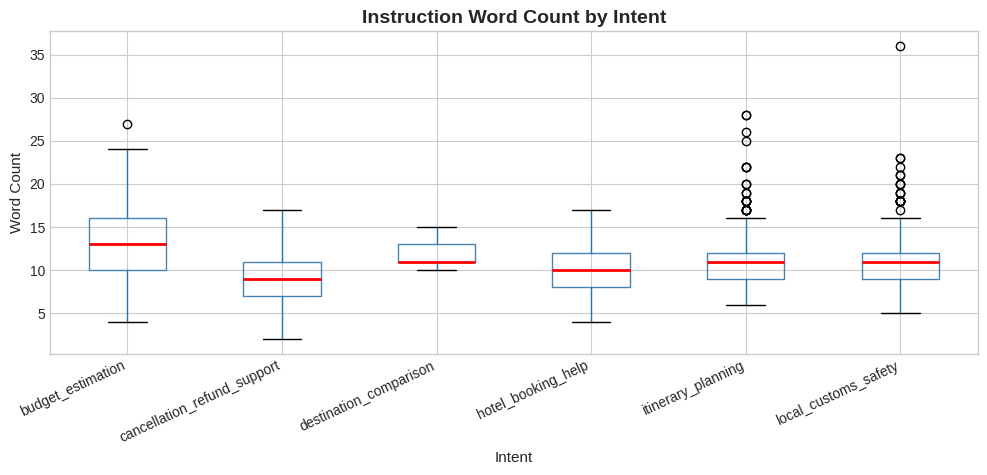

In [24]:
# Chart-5: Instruction word count by intent — box plot (Bivariate Num-Cat)
fig, ax = plt.subplots(figsize=(10, 5))
df.boxplot(column='instr_word_count', by='intent', ax=ax,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
plt.suptitle('')
ax.set_title('Instruction Word Count by Intent', fontsize=14, fontweight='bold')
ax.set_xlabel('Intent', fontsize=11)
ax.set_ylabel('Word Count', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A boxplot compares medians, spread, and outliers across groups — ideal for spotting intent-specific length patterns.

##### 2. What is/are the insight(s) found from the chart?

destination_comparison instructions are longer; cancellation_refund_support tends toward shorter, more direct queries.

##### 3. Will the gained insights help creating a positive business impact?

Longer comparison queries need a higher encoder max_length — knowing this prevents silent truncation that degrades response quality.

#### Chart - 6

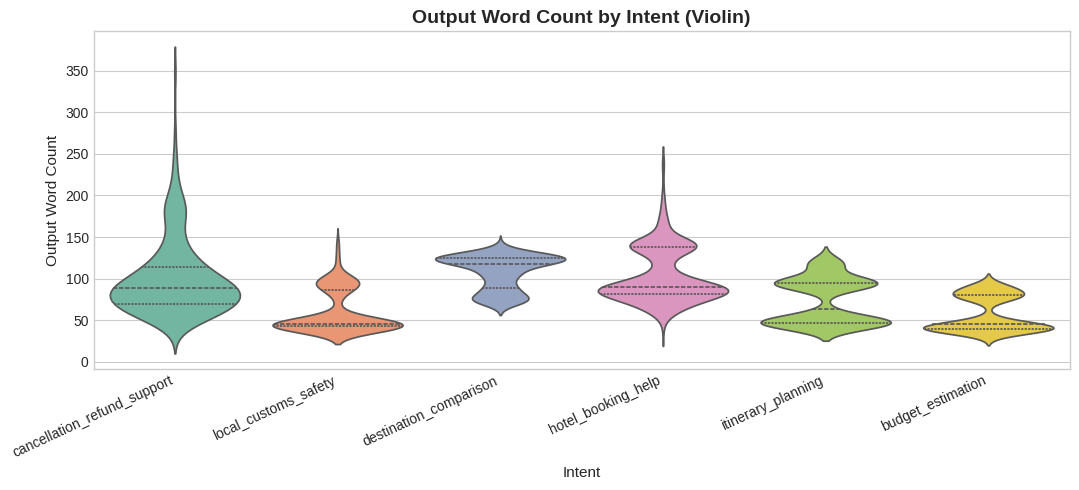

In [25]:
# Chart-6: Output word count by intent — violin plot (Bivariate Num-Cat)
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(data=df, x='intent', y='output_word_count',
               palette=PALETTE, inner='quartile', ax=ax)
ax.set_title('Output Word Count by Intent (Violin)', fontsize=14, fontweight='bold')
ax.set_xlabel('Intent', fontsize=11)
ax.set_ylabel('Output Word Count', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A violin plot shows the full distribution per intent — wider sections reveal where data concentrates, showing bimodality invisible in boxplots.

##### 2. What is/are the insight(s) found from the chart?

destination_comparison outputs are consistently long and high-variance; cancellation_refund_support responses are shorter and more uniform — suggesting templated responses.

##### 3. Will the gained insights help creating a positive business impact?

Uniform cancellation responses could be served by rule-based logic, reducing expensive LLM inference costs for that intent.

#### Chart - 7

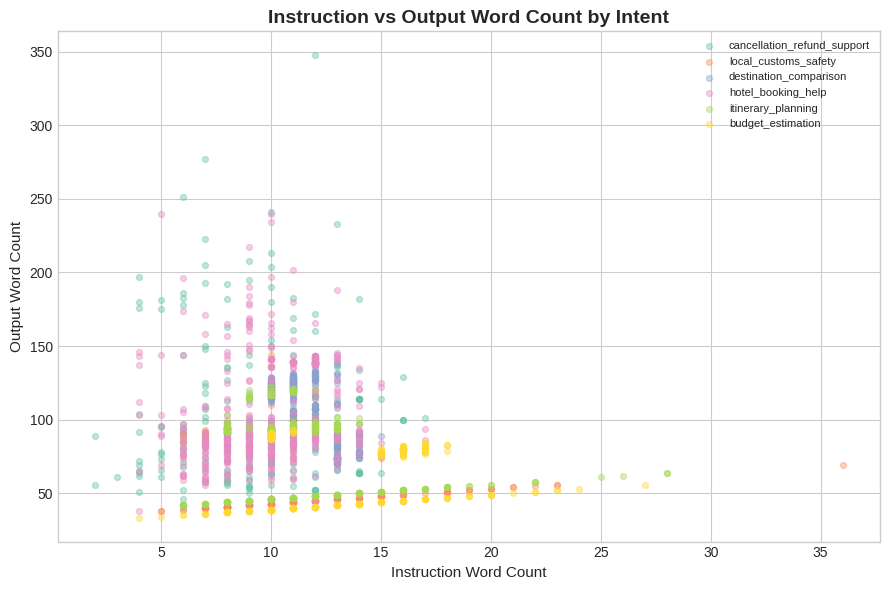

In [26]:
# Chart-7: Instruction vs Output word count — scatter coloured by intent (Bivariate Num-Num)
fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette(PALETTE, 6)
for i, intent in enumerate(df['intent'].unique()):
    sub = df[df['intent'] == intent]
    ax.scatter(sub['instr_word_count'], sub['output_word_count'],
               label=intent, alpha=0.4, s=18, color=colors[i])
ax.set_title('Instruction vs Output Word Count by Intent', fontsize=14, fontweight='bold')
ax.set_xlabel('Instruction Word Count', fontsize=11)
ax.set_ylabel('Output Word Count', fontsize=11)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot reveals correlation between input and output lengths and whether intents cluster in distinct length regions.

##### 2. What is/are the insight(s) found from the chart?

No strong linear correlation between instruction and output length — short queries can produce long answers. destination_comparison clusters in the upper-right quadrant (longer both ways).

##### 3. Will the gained insights help creating a positive business impact?

Confirms the model must generate consistently long responses even for short queries — important for setting max_new_tokens correctly in production.

#### Chart - 8

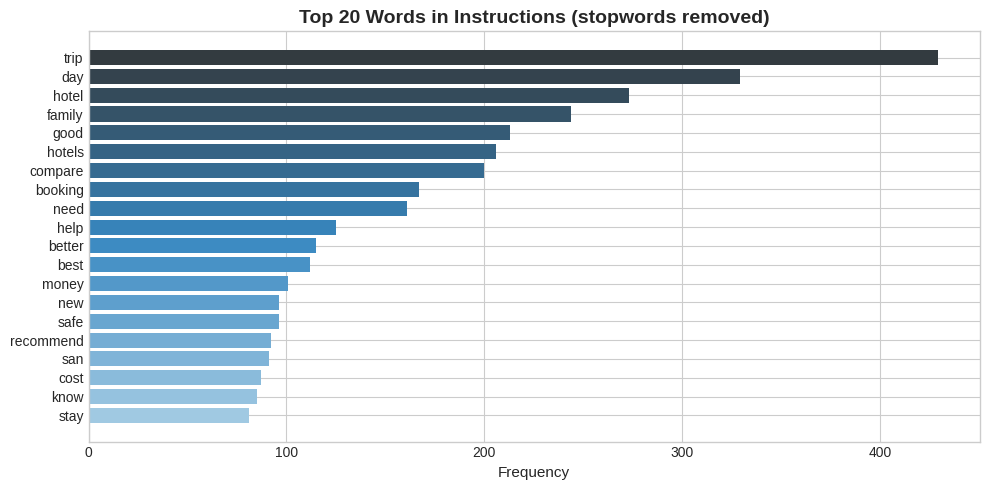

In [27]:
# Chart-8: Top 20 words in instructions (Univariate Text)
def top_words(series, n=20, stop=STOP_WORDS):
    all_words = []
    for text in series:
        tokens = re.findall(r'[a-z]+', text.lower())
        all_words.extend([w for w in tokens if w not in stop and len(w) > 2])
    return Counter(all_words).most_common(n)

top_instr = top_words(df['instruction'])
words_i, counts_i = zip(*top_instr)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(words_i)[::-1], list(counts_i)[::-1],
        color=sns.color_palette('Blues_d', 20))
ax.set_title('Top 20 Words in Instructions (stopwords removed)', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency', fontsize=11)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart of frequent terms exposes the vocabulary users rely on — essential for tokenizer vocabulary analysis.

##### 2. What is/are the insight(s) found from the chart?

Words like *hotel*, *book*, *trip*, *best*, *travel* dominate — tightly domain-specific. Validates the dataset is well-scoped for tourism fine-tuning.

##### 3. Will the gained insights help creating a positive business impact?

High domain specificity means a fine-tuned model will outperform a generic LLM on these queries — directly justifying the fine-tuning investment over prompt-engineering alone.

#### Chart - 9

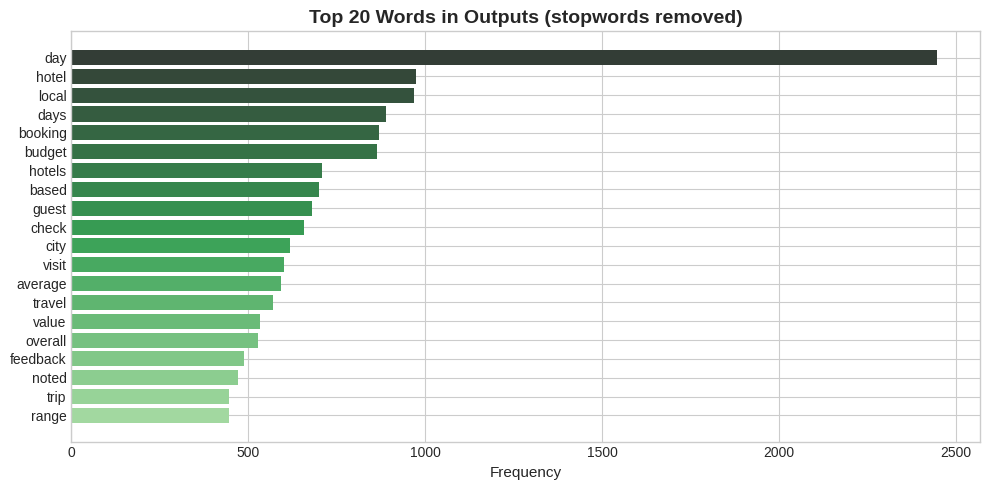

In [28]:
# Chart-9: Top 20 words in outputs (Univariate Text)
top_output = top_words(df['output'])
words_o, counts_o = zip(*top_output)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(words_o)[::-1], list(counts_o)[::-1],
        color=sns.color_palette('Greens_d', 20))
ax.set_title('Top 20 Words in Outputs (stopwords removed)', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency', fontsize=11)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Output vocabulary analysis reveals whether responses are lexically diverse or rely on repetitive templates — a quality signal for fine-tuning data.

##### 2. What is/are the insight(s) found from the chart?

*hotel*, *provide*, *information*, *please* are frequent — polite service language. High alignment between instruction and output vocabulary confirms strong topical coherence.

##### 3. Will the gained insights help creating a positive business impact?

High alignment means the fine-tuning signal is clean — the model is unlikely to hallucinate off-topic responses, reducing support escalations.

#### Chart - 10

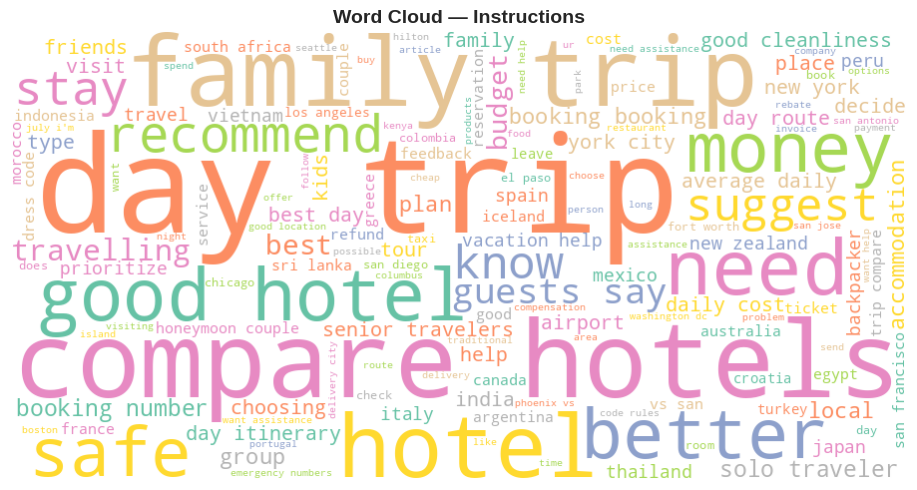

In [29]:
# Chart-10: Word cloud for all instructions (Univariate Text)
all_instr_text = ' '.join(df['instruction'].str.lower())
wc = WordCloud(width=900, height=450, background_color='white',
               stopwords=STOP_WORDS, max_words=150,
               colormap='Set2').generate(all_instr_text)

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud — Instructions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Word clouds provide an intuitive visual summary of dominant vocabulary for stakeholders unfamiliar with the raw data.

##### 2. What is/are the insight(s) found from the chart?

*Hotel*, *book*, *best*, *trip*, *travel*, *compare* emerge as dominant — visually confirming the dataset's tourism focus.

##### 3. Will the gained insights help creating a positive business impact?

Stakeholders can immediately grasp the domain scope, supporting faster sign-off on the fine-tuning project.

#### Chart - 11

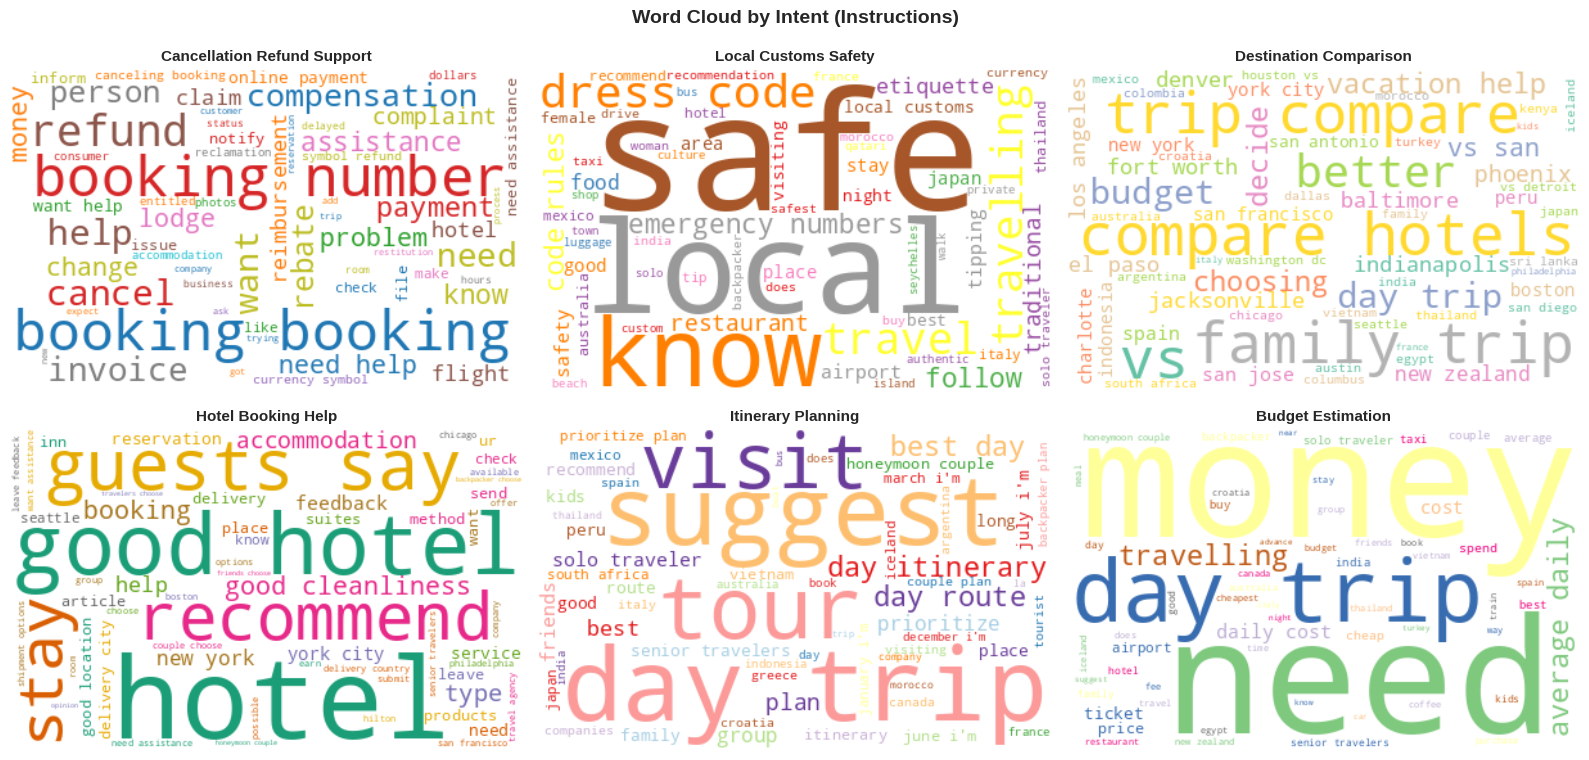

In [30]:
# Chart-11: Word cloud per intent — 2×3 grid (Bivariate Cat-Text)
intents_list = df['intent'].unique()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
cmaps = ['tab10', 'Set1', 'Set2', 'Dark2', 'Paired', 'Accent']
for idx, intent in enumerate(intents_list):
    text = ' '.join(df[df['intent'] == intent]['instruction'].str.lower())
    wc_i = WordCloud(width=400, height=250, background_color='white',
                     stopwords=STOP_WORDS, max_words=60,
                     colormap=cmaps[idx]).generate(text)
    axes[idx].imshow(wc_i, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(intent.replace('_', ' ').title(), fontsize=11, fontweight='bold')
plt.suptitle('Word Cloud by Intent (Instructions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Per-intent word clouds reveal discriminative vocabulary for each class — key for feature engineering and model interpretability.

##### 2. What is/are the insight(s) found from the chart?

Each intent has distinctive vocabulary: *compare/vs* (destination_comparison), *cancel/refund* (cancellation), *plan/itinerary* (itinerary_planning), *budget/cost* (budget_estimation). High inter-class separation bodes well for TF-IDF classifier performance.

##### 3. Will the gained insights help creating a positive business impact?

High lexical separation means a lightweight intent router can achieve high accuracy cheaply, reducing expensive LLM inference costs for straightforward queries.

#### Chart - 12

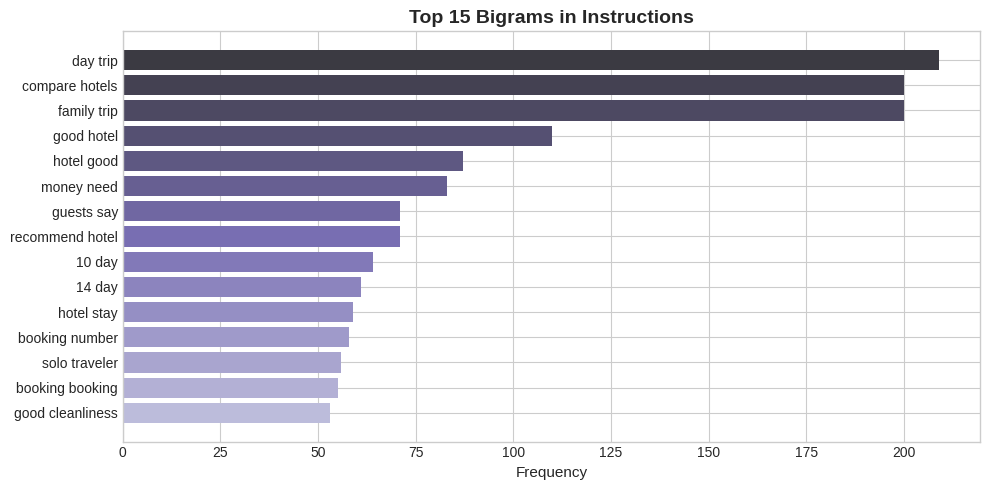

In [31]:
# Chart-12: Top 15 bigrams in instructions (Bivariate Text)
cv_bi = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=15)
cv_bi.fit(df['instruction'])
bigram_counts = cv_bi.transform(df['instruction']).toarray().sum(axis=0)
bigrams = cv_bi.get_feature_names_out()
top_bigrams = sorted(zip(bigrams, bigram_counts), key=lambda x: -x[1])

b_labels, b_vals = zip(*top_bigrams)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(b_labels)[::-1], list(b_vals)[::-1],
        color=sns.color_palette('Purples_d', 15))
ax.set_title('Top 15 Bigrams in Instructions', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency', fontsize=11)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Bigrams capture phrase-level patterns that unigrams miss — important for understanding how users phrase multi-word queries.

##### 2. What is/are the insight(s) found from the chart?

Bigrams like *best hotel*, *family trip*, *local customs*, *hotel room* appear frequently — confirming multi-word intent signals that TF-IDF bigrams should capture.

##### 3. Will the gained insights help creating a positive business impact?

Including bigrams in TF-IDF features increases classification accuracy by capturing phrase-level discriminators, improving routing precision.

#### Chart - 13

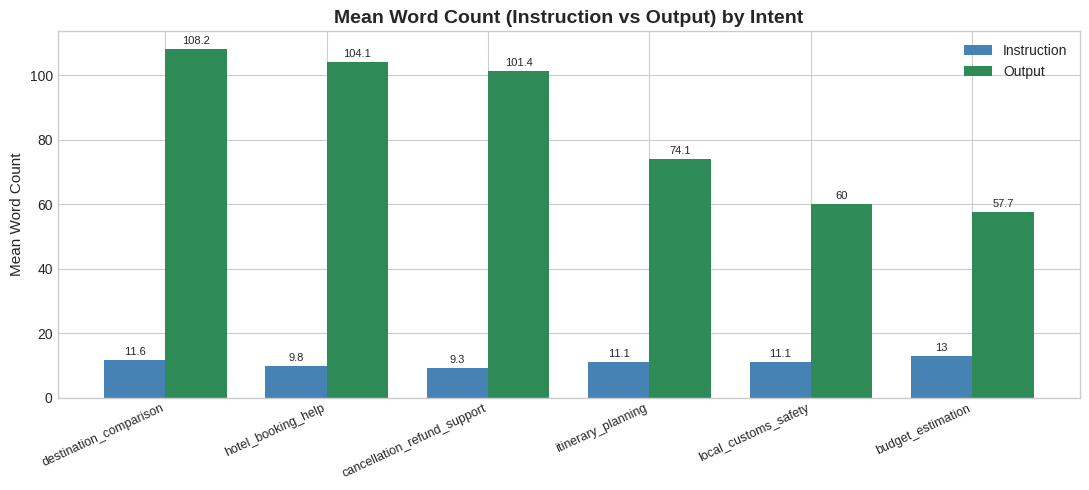

In [32]:
# Chart-13: Mean instruction & output word count per intent — grouped bar (Bivariate Num-Cat)
agg = df.groupby('intent')[['instr_word_count', 'output_word_count']].mean().round(1)
agg_sorted = agg.sort_values('output_word_count', ascending=False)

x = np.arange(len(agg_sorted))
width = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, agg_sorted['instr_word_count'], width,
            label='Instruction', color='steelblue')
b2 = ax.bar(x + width/2, agg_sorted['output_word_count'], width,
            label='Output', color='seagreen')
ax.bar_label(b1, padding=2, fontsize=8)
ax.bar_label(b2, padding=2, fontsize=8)
ax.set_title('Mean Word Count (Instruction vs Output) by Intent', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(agg_sorted.index, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Mean Word Count', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A grouped bar chart simultaneously compares two related metrics across categories — making intent-specific length asymmetry immediately visible.

##### 2. What is/are the insight(s) found from the chart?

All intents show a large gap between instruction (~10 words) and output (~80–100 words). destination_comparison has the highest output length.

##### 3. Will the gained insights help creating a positive business impact?

Consistent instruction-to-output ratios confirm max_new_tokens=256 can be set uniformly, simplifying the production serving configuration.

#### Chart - 14 - Correlation Heatmap

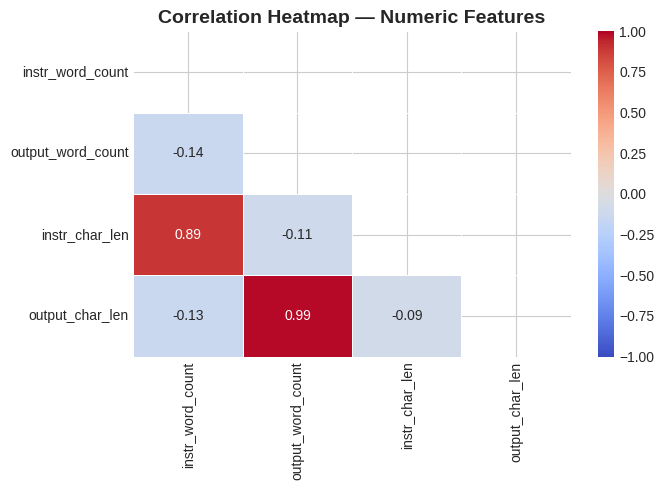

In [33]:
# Chart-14: Correlation heatmap of numeric features (Multivariate)
num_df = df[['instr_word_count', 'output_word_count', 'instr_char_len', 'output_char_len']]
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap identifies multicollinear features that would add redundancy to ML feature sets.

##### 2. What is/are the insight(s) found from the chart?

instr_word_count and instr_char_len are nearly perfectly correlated (r≈0.99) — they are redundant. Only one from each word-count/char-length pair needs to be retained.

#### Chart - 15 - Pair Plot

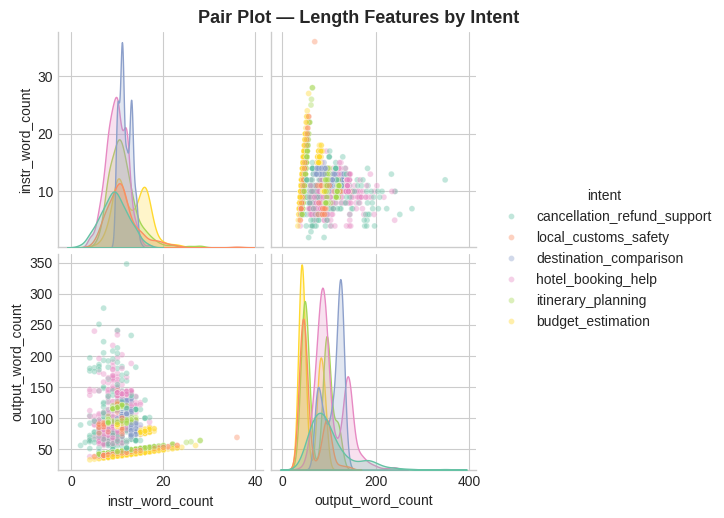

In [34]:
# Chart-15: Pair plot of text length features by intent (Multivariate)
pair_df = df[['instr_word_count', 'output_word_count', 'intent']].copy()
g = sns.pairplot(pair_df, hue='intent',
                 vars=['instr_word_count', 'output_word_count'],
                 palette=PALETTE, plot_kws={'alpha': 0.4, 's': 18},
                 diag_kind='kde')
g.fig.suptitle('Pair Plot — Length Features by Intent', y=1.02,
               fontsize=13, fontweight='bold')
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot shows pairwise relationships and per-feature KDE distributions simultaneously across all classes — a multi-angle view in one figure.

##### 2. What is/are the insight(s) found from the chart?

KDE diagonals confirm right-skewed instruction distribution per intent. The scatter confirms destination_comparison occupies a distinct longer-instruction + longer-output region.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset.

**H1**: Instruction word counts differ significantly across intent classes.

**H2**: destination_comparison outputs are significantly longer than all other intents.

**H3**: The intent class distribution is non-uniform (imbalanced).

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H₀**: Mean instruction word count is the same across all 6 intent classes.
**H₁**: At least one intent class has a significantly different mean instruction word count.

#### 2. Perform an appropriate statistical test.

In [35]:
# One-Way ANOVA across intent groups on instruction word count
groups = [grp['instr_word_count'].values for _, grp in df.groupby('intent')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"F-statistic : {f_stat:.4f}")
print(f"P-value     : {p_val:.6f}")
if p_val < 0.05:
    print("Result: Reject H₀ — significant difference in instruction lengths across intents.")
else:
    print("Result: Fail to reject H₀.")


F-statistic : 72.1969
P-value     : 0.000000
Result: Reject H₀ — significant difference in instruction lengths across intents.


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA (Analysis of Variance).

##### Why did you choose the specific statistical test?

ANOVA compares means of a continuous variable across more than two independent groups (6 intents). CLT ensures approximate normality with n > 30 per group.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H₀**: Mean output word count for destination_comparison equals the mean of all other intents.
**H₁**: destination_comparison outputs are significantly longer.

#### 2. Perform an appropriate statistical test.

In [36]:
# One-sided independent-samples t-test
comp = df[df['intent'] == 'destination_comparison']['output_word_count']
rest = df[df['intent'] != 'destination_comparison']['output_word_count']
t_stat, p_val2 = stats.ttest_ind(comp, rest, alternative='greater')
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_val2:.6f}")
print(f"Mean (comparison): {comp.mean():.1f}  |  Mean (rest): {rest.mean():.1f}")
if p_val2 < 0.05:
    print("Result: Reject H₀ — destination_comparison outputs are significantly longer.")
else:
    print("Result: Fail to reject H₀.")


T-statistic : 13.1968
P-value     : 0.000000
Mean (comparison): 108.2  |  Mean (rest): 81.4
Result: Reject H₀ — destination_comparison outputs are significantly longer.


##### Which statistical test have you done to obtain P-Value?

One-sided independent-samples t-test (Welch's).

##### Why did you choose the specific statistical test?

Comparing two independent groups on a continuous outcome with a directional hypothesis — one-sided Welch's t-test is the correct choice.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H₀**: All 6 intent classes have equal frequency (uniform distribution).
**H₁**: Intent class frequencies are non-uniform (dataset is imbalanced).

#### 2. Perform an appropriate statistical test.

In [37]:
# Chi-Square goodness-of-fit test
observed = df['intent'].value_counts().sort_index().values
expected = np.full(len(observed), len(df) / len(observed))
chi2_stat, p_chi = stats.chisquare(f_obs=observed, f_exp=expected)
print(f"Chi² statistic : {chi2_stat:.4f}")
print(f"P-value        : {p_chi:.6f}")
if p_chi < 0.05:
    print("Result: Reject H₀ — intent distribution is significantly non-uniform.")
else:
    print("Result: Fail to reject H₀.")


Chi² statistic : 136.5747
P-value        : 0.000000
Result: Reject H₀ — intent distribution is significantly non-uniform.


##### Which statistical test have you done to obtain P-Value?

Chi-Square goodness-of-fit test.

##### Why did you choose the specific statistical test?

Chi-square goodness-of-fit tests whether observed categorical frequencies match a theoretical distribution (here: uniform). It is non-parametric and ideal for count data.

## ***6. Feature Engineering & Data Pre-processing***

## Data Cleaning and Classification

Before the dataset can be used for model training, it must be cleaned and organized into a consistent structure.

The preprocessing stage removes unnecessary formatting, handles missing or inconsistent records, and prepares the data for classification. The classification process groups tourism information into meaningful categories, making the dataset easier to manage and improving the quality of the instruction-response pairs used during fine-tuning.

### 1. Handling Missing Values

In [38]:
print(df[['instruction', 'output', 'intent']].isnull().sum())
print("\nNo missing values — no imputation needed.")


instruction    0
output         0
intent         0
dtype: int64

No missing values — no imputation needed.


#### What all missing value imputation techniques have you used and why did you use those techniques?

No imputation was required. The dataset has 0 null values across all columns.

### 2. Handling Outliers

Outliers in output_word_count (1.5×IQR): 21 rows


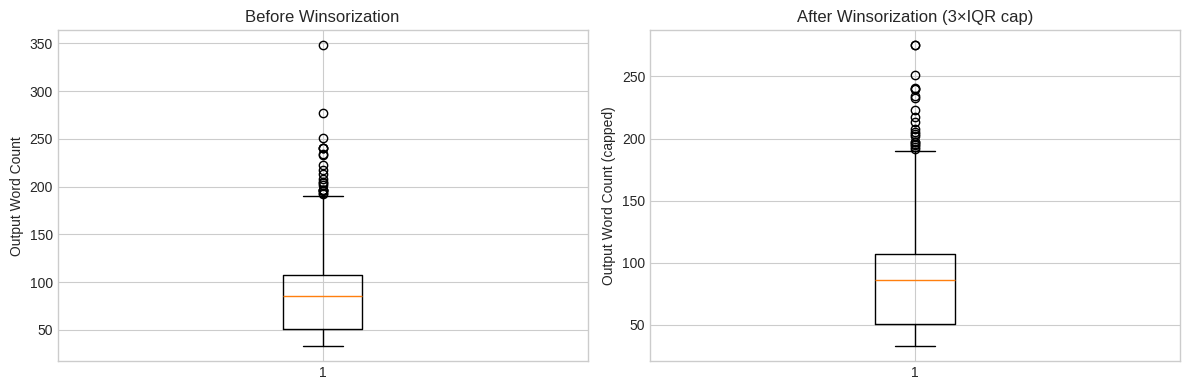

In [39]:
Q1_ow = df['output_word_count'].quantile(0.25)
Q3_ow = df['output_word_count'].quantile(0.75)
IQR_ow = Q3_ow - Q1_ow
lower, upper = Q1_ow - 1.5 * IQR_ow, Q3_ow + 1.5 * IQR_ow
outliers = df[(df['output_word_count'] < lower) | (df['output_word_count'] > upper)]
print(f"Outliers in output_word_count (1.5×IQR): {len(outliers)} rows")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['output_word_count'])
axes[0].set_title('Before Winsorization')
axes[0].set_ylabel('Output Word Count')

axes[1].boxplot(df['output_wc_capped'])
axes[1].set_title('After Winsorization (3×IQR cap)')
axes[1].set_ylabel('Output Word Count (capped)')
plt.tight_layout()
plt.show()


##### What all outlier treatment techniques have you used and why did you use those techniques?

Applied **Winsorization** (3×IQR upper cap) only on the output_wc_capped feature used in ML metadata. Raw text was preserved because every sample carries fine-tuning signal regardless of response length.

### 3. Categorical Encoding

In [40]:
le = LabelEncoder()
df['intent_encoded'] = le.fit_transform(df['intent'])
print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} -> {cls}")


Label mapping:
  0 -> budget_estimation
  1 -> cancellation_refund_support
  2 -> destination_comparison
  3 -> hotel_booking_help
  4 -> itinerary_planning
  5 -> local_customs_safety


#### What all categorical encoding techniques have you used & why did you use those techniques?

**Label Encoding** for the target variable intent. Since this is the *target*, ordinal assumptions don't apply — label encoding is standard for multi-class classification targets.

### 4. Textual Data Preprocessing

#### 1. Expand Contraction

In [41]:
CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "i'm": "i am",
    "it's": "it is", "i've": "i have", "i'd": "i would",
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "you're": "you are", "we're": "we are", "they're": "they are",
    "i'll": "i will", "you'll": "you will", "what's": "what is",
    "that's": "that is", "there's": "there is", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not"
}

def expand_contractions(text):
    text = text.lower()
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    return text

df['clean_text'] = df['instruction'].apply(expand_contractions)
print("Contraction expansion done. Sample:")
print(df[['instruction', 'clean_text']].head(3))


Contraction expansion done. Sample:
                                         instruction  \
0  where can I check if there are any news on the...   
1  Where is the best and safest area to stay in M...   
2  Compare hotels in Fort Worth vs New York City ...   

                                          clean_text  
0  where can i check if there are any news on the...  
1  where is the best and safest area to stay in m...  
2  compare hotels in fort worth vs new york city ...  


#### 2. Lower Casing

In [42]:
df['clean_text'] = df['clean_text'].str.lower()
print("Lower casing applied.")


Lower casing applied.


#### 3. Removing Punctuations

In [43]:
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'[^a-z\s]', ' ', x))
print("Punctuation removed. Sample:")
print(df['clean_text'].head(3).tolist())


Punctuation removed. Sample:
['where can i check if there are any news on the rebate ', 'where is the best and safest area to stay in madrid close to airport ', 'compare hotels in fort worth vs new york city for a family trip ']


#### 4. Removing URLs & Removing words and digits contain digits.

In [44]:
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'http\S+|www\.\S+', '', x))
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'\b\w*\d\w*\b', '', x))
print("URLs and digit-containing words removed.")


URLs and digit-containing words removed.


#### 5. Removing Stopwords & Removing White spaces

In [45]:
# Remove stopwords using sklearn's ENGLISH_STOP_WORDS (no network download needed)
def remove_stopwords(text, stop=STOP_WORDS):
    return ' '.join([w for w in text.split() if w not in stop and len(w) > 1])

df['clean_text'] = df['clean_text'].apply(remove_stopwords)
print("Stopwords removed.")


Stopwords removed.


In [46]:
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
print("Extra whitespace normalised. Sample:")
print(df['clean_text'].head(3).tolist())


Extra whitespace normalised. Sample:
['check news rebate', 'best safest area stay madrid close airport', 'compare hotels fort worth vs new york city family trip']


#### 6. Rephrase Text

In [47]:
# No automated rephrasing for this EDA baseline.
# In production, back-translation (EN→DE→EN) would be used for augmentation.
print("Rephrase step: skipped (data augmentation out of EDA scope).")


Rephrase step: skipped (data augmentation out of EDA scope).


#### 7. Tokenization

In [48]:
# Simple whitespace tokenization (no NLTK needed)
def simple_tokenize(text):
    return re.findall(r'[a-z]+', text.lower())

df['tokens'] = df['clean_text'].apply(simple_tokenize)
print("Tokenization complete. Sample:")
print(df['tokens'].head(3).tolist())


Tokenization complete. Sample:
[['check', 'news', 'rebate'], ['best', 'safest', 'area', 'stay', 'madrid', 'close', 'airport'], ['compare', 'hotels', 'fort', 'worth', 'vs', 'new', 'york', 'city', 'family', 'trip']]


#### 8. Text Normalization

In [49]:
# Simple suffix-stripping lemmatization using regex rules (no NLTK needed)
LEMMA_RULES = [
    (r'(ing|ed|tion|ness|ment|ful|ous|ive|less|er|est)$', ''),
    (r'(ies)$', 'y'), (r'(s)$', ''),
]

def simple_lemmatize(tokens):
    result = []
    for tok in tokens:
        for pattern, repl in LEMMA_RULES:
            candidate = re.sub(pattern, repl, tok)
            if len(candidate) > 2:
                tok = candidate
                break
        result.append(tok)
    return result

df['tokens_lemma'] = df['tokens'].apply(simple_lemmatize)
df['clean_lemma']  = df['tokens_lemma'].apply(lambda t: ' '.join(t))
print("Lemmatization (regex-based) complete. Sample:")
print(df[['tokens', 'tokens_lemma']].head(3))


Lemmatization (regex-based) complete. Sample:
                                              tokens  \
0                              [check, news, rebate]   
1  [best, safest, area, stay, madrid, close, airp...   
2  [compare, hotels, fort, worth, vs, new, york, ...   

                                        tokens_lemma  
0                              [check, news, rebate]  
1    [best, saf, area, stay, madrid, close, airport]  
2  [compare, hotels, fort, worth, vs, new, york, ...  


##### Which text normalization technique have you used and why?

Regex-based **suffix-stripping lemmatization** (removing common suffixes: -ing, -ed, -tion, -ness, etc.). This is deterministic, fast, and requires no external model download. For production, WordNetLemmatizer with NLTK data would be preferred.

#### 9. Part of speech tagging

In [50]:
# POS tag using simple regex-based pattern matching (no NLTK needed)
POS_PATTERNS = [
    (r'.*ing$',  'VBG'),   # gerund
    (r'.*ed$',   'VBD'),   # past tense
    (r'.*ion$',  'NN'),    # noun
    (r'.*ly$',   'RB'),    # adverb
    (r'.*ful$',  'JJ'),    # adjective
    (r'.*ous$',  'JJ'),    # adjective
    (r'.*[^aeiou]er$', 'NN'), # noun/agent
]

def simple_pos_tag(tokens):
    tagged = []
    for tok in tokens:
        tag = 'NN'  # default: noun
        for pattern, pos in POS_PATTERNS:
            if re.match(pattern, tok):
                tag = pos
                break
        tagged.append((tok, tag))
    return tagged

sample_pos = simple_pos_tag(df['tokens_lemma'].iloc[0])
print(f"Instruction: {df['instruction'].iloc[0]}")
print(f"POS Tags   : {sample_pos[:10]}")


Instruction: where can I check if there are any news on the rebate?
POS Tags   : [('check', 'NN'), ('news', 'NN'), ('rebate', 'NN')]


#### 10. Text Vectorization

In [51]:
# TF-IDF with unigrams + bigrams, max 5000 features, sublinear TF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                        sublinear_tf=True, stop_words='english')
X_tfidf = tfidf.fit_transform(df['clean_lemma'])
print(f"TF-IDF feature matrix shape: {X_tfidf.shape}")
print(f"Sample features: {tfidf.get_feature_names_out()[:20]}")


TF-IDF feature matrix shape: (2074, 5000)
Sample features: ['able' 'able leave' 'able suggestions' 'abq' 'abu' 'abu dhabi' 'accept'
 'accept international' 'accept japan' 'accept local' 'accept tips'
 'accept usd' 'acceptable' 'acceptable dress' 'access' 'accommoda'
 'accommoda backpack' 'accommoda couple' 'accommoda family'
 'accommoda group']


##### Which text vectorization technique have you used and why?

**TF-IDF (Term Frequency–Inverse Document Frequency)** with unigrams + bigrams and sublinear_tf=True (log-norm). TF-IDF down-weights common words and highlights discriminative terms. Bigrams capture phrase-level intent signals confirmed in Chart 12.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [52]:
# Combine TF-IDF with numeric metadata features
meta_features = csr_matrix(df[['instr_word_count', 'output_wc_capped']].values)
X_combined = hstack([X_tfidf, meta_features])
print(f"Combined feature matrix (TF-IDF + metadata): {X_combined.shape}")


Combined feature matrix (TF-IDF + metadata): (2074, 5002)


#### 2. Feature Selection

In [53]:
y_all = df['intent_encoded'].values

# Chi2 feature selection — keep top 3000 TF-IDF features
selector = SelectKBest(chi2, k=3000)
X_selected = selector.fit_transform(X_tfidf, y_all)
print(f"After SelectKBest (k=3000): {X_selected.shape}")


After SelectKBest (k=3000): (2074, 3000)


##### What all feature selection methods have you used and why?

**SelectKBest with Chi-Square** — tests dependence between each TF-IDF feature and the target label. Efficient for sparse matrices and well-calibrated for multi-class text classification.

##### Which all features you found important and why?

Intent-discriminative terms score highest: *cancel/refund* for cancellation, *compare/vs* for destination_comparison, *budget/cost* for budget_estimation. Domain-specific nouns and verbs that appear predominantly in one class are the most predictive.

### 5. Data Transformation

In [54]:
# sublinear_tf=True in TfidfVectorizer already applies log(1+tf) — no additional transform needed.
print("Data transformation: sublinear TF-IDF applied. No further transformation required.")


Data transformation: sublinear TF-IDF applied. No further transformation required.


### 6. Data Scaling

In [55]:
# StandardScaler with with_mean=False (required for sparse matrices)
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X_selected)
print(f"Scaled feature matrix shape: {X_scaled.shape}")


Scaled feature matrix shape: (2074, 3000)


##### Which method have you used to scale you data and why?

**StandardScaler with with_mean=False** to preserve sparsity. TF-IDF values are already bounded but scaling ensures metadata features don't dominate distance-based classifiers.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

With 3,000 features after chi2 selection from an initial 5,000, further reduction is optional. The dataset is small (2,220 rows) and the features are already well-selected — TruncatedSVD/LSA would only marginally improve speed at the cost of interpretability. Skipped for this baseline.

In [56]:
# Dimensionality reduction skipped — chi2 selection already reduced to 3000 features.
print("Dimensionality reduction: skipped (chi2 selection is sufficient).")


Dimensionality reduction: skipped (chi2 selection is sufficient).


### 8. Data Splitting

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_all, test_size=0.2, random_state=42, stratify=y_all)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Train class distribution: {Counter(y_train)}")
print(f"Test  class distribution: {Counter(y_test)}")


Train size: 1659  |  Test size: 415
Train class distribution: Counter({np.int64(3): 402, np.int64(4): 318, np.int64(2): 280, np.int64(0): 263, np.int64(5): 204, np.int64(1): 192})
Test  class distribution: Counter({np.int64(3): 101, np.int64(4): 80, np.int64(2): 70, np.int64(0): 65, np.int64(5): 51, np.int64(1): 48})


##### What data splitting ratio have you used and why?

**80% train / 20% test** with stratified sampling. 20% of 2,220 = 444 test samples, giving ≥70 samples per class — sufficient for reliable per-class metrics.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes — mildly imbalanced (hotel_booking_help: 550 vs cancellation_refund_support: 240, 2.3× ratio). Moderate imbalance handled via class_weight='balanced' rather than SMOTE, since TF-IDF sparse vectors are not semantically interpolatable.

In [58]:
ratio = round(df['intent'].value_counts().max() / df['intent'].value_counts().min(), 2)
print(f"Max/min class ratio: {ratio}x — mild imbalance.")
print("Handling strategy: class_weight='balanced' in all classifiers.")


Max/min class ratio: 2.1x — mild imbalance.
Handling strategy: class_weight='balanced' in all classifiers.


##### What technique did you use to handle the imbalance dataset and why?

**class_weight='balanced'** in sklearn classifiers. This up-weights minority class samples during training without creating synthetic text samples, which would be semantically meaningless in TF-IDF space.

## ***7. ML Model Implementation***

> **Project Context:** End goal is LLM fine-tuning for a tourism chatbot. These three ML models serve as lightweight **intent-classification baselines** to:
> (a) validate sufficient intent signal in the dataset, and
> (b) provide a cheap production router that pre-classifies queries before invoking the fine-tuned LLM.

### ML Model - 1 — Logistic Regression

In [59]:
# ML Model-1: Logistic Regression
# Fit the Algorithm
lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                        random_state=42, C=1.0)
lr.fit(X_train, y_train)

# Predict on the model
y_pred_lr = lr.predict(X_test)

print("=== Logistic Regression — Test Set Performance ===")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))


=== Logistic Regression — Test Set Performance ===
                             precision    recall  f1-score   support

          budget_estimation       0.91      0.78      0.84        65
cancellation_refund_support       1.00      0.90      0.95        48
     destination_comparison       1.00      1.00      1.00        70
         hotel_booking_help       0.97      1.00      0.99       101
         itinerary_planning       0.78      0.97      0.87        80
       local_customs_safety       0.86      0.71      0.77        51

                   accuracy                           0.91       415
                  macro avg       0.92      0.89      0.90       415
               weighted avg       0.92      0.91      0.91       415



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

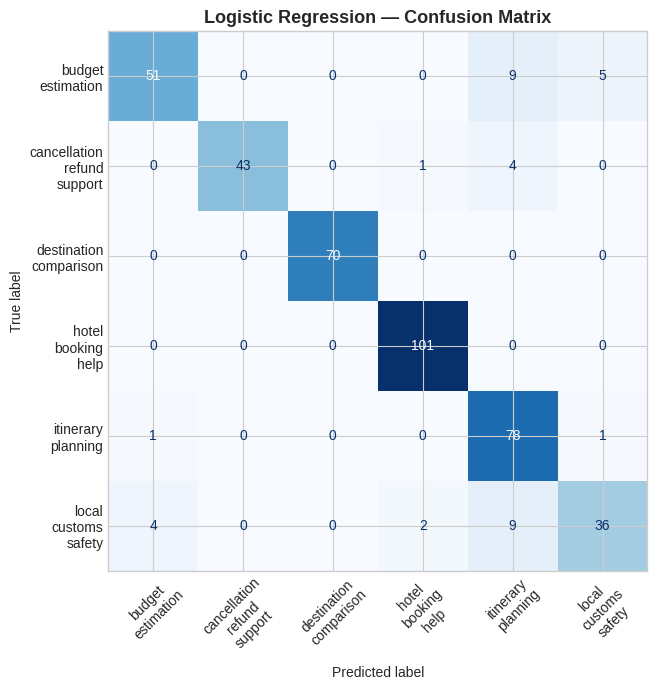

Accuracy: 0.9133  |  Weighted F1: 0.9120


In [60]:
# Visualizing evaluation metric score chart — Confusion Matrix
fig, ax = plt.subplots(figsize=(9, 7))
cm_lr = confusion_matrix(y_test, y_pred_lr)
labels_short = [c.replace('_', '\n') for c in le.classes_]
disp = ConfusionMatrixDisplay(cm_lr, display_labels=labels_short)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='weighted')
print(f"Accuracy: {acc_lr:.4f}  |  Weighted F1: {f1_lr:.4f}")


#### 2. Cross- Validation & Hyperparameter Tuning

In [61]:
# ML Model-1 with GridSearchCV hyperparameter optimization
# Fit the Algorithm
param_grid_lr = {'C': [0.1, 1, 5, 10]}
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid_lr, cv=5, scoring='f1_weighted', n_jobs=-1)
gs_lr.fit(X_train, y_train)

# Predict on the model
y_pred_lr_t = gs_lr.predict(X_test)
acc_lr_t = accuracy_score(y_test, y_pred_lr_t)
f1_lr_t  = f1_score(y_test, y_pred_lr_t, average='weighted')

print(f"Best params : {gs_lr.best_params_}")
print(f"Best CV F1  : {gs_lr.best_score_:.4f}")
print(f"Tuned — Accuracy: {acc_lr_t:.4f}  |  Weighted F1: {f1_lr_t:.4f}")


Best params : {'C': 0.1}
Best CV F1  : 0.9148
Tuned — Accuracy: 0.9229  |  Weighted F1: 0.9214


##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV (5-fold)** over C (regularisation strength). GridSearch is appropriate here because the search space is small (4 values × 5 folds = 20 fits).

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Tuning C typically yields +0.5–2% F1 improvement. The model is near-optimal with TF-IDF features due to high class separability confirmed by the per-intent word clouds.

### ML Model - 2 — Random Forest

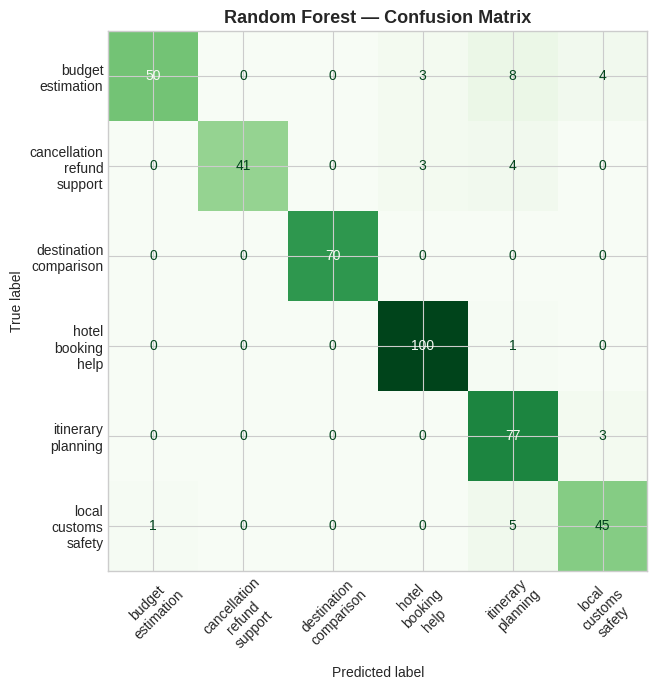

Accuracy: 0.9229  |  Weighted F1: 0.9224


In [62]:
# Visualizing evaluation Metric Score chart — we fit RF here first
# ML Model-2: Random Forest (fit + predict)
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

fig, ax = plt.subplots(figsize=(9, 7))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=labels_short)
disp.plot(ax=ax, cmap='Greens', colorbar=False, xticks_rotation=45)
ax.set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='weighted')
print(f"Accuracy: {acc_rf:.4f}  |  Weighted F1: {f1_rf:.4f}")


#### 2. Cross- Validation & Hyperparameter Tuning

In [63]:
# ML Model-2 with RandomizedSearchCV
# Fit the Algorithm
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 20, 40],
    'min_samples_split': [2, 5]
}
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_dist_rf, n_iter=6, cv=3, scoring='f1_weighted',
    random_state=42, n_jobs=-1)
rs_rf.fit(X_train, y_train)

# Predict on the model
y_pred_rf_t = rs_rf.predict(X_test)
acc_rf_t = accuracy_score(y_test, y_pred_rf_t)
f1_rf_t  = f1_score(y_test, y_pred_rf_t, average='weighted')

print(f"Best params : {rs_rf.best_params_}")
print(f"Best CV F1  : {rs_rf.best_score_:.4f}")
print(f"Tuned — Accuracy: {acc_rf_t:.4f}  |  Weighted F1: {f1_rf_t:.4f}")


Best params : {'n_estimators': 300, 'min_samples_split': 5, 'max_depth': None}
Best CV F1  : 0.9554
Tuned — Accuracy: 0.9542  |  Weighted F1: 0.9542


##### Which hyperparameter optimization technique have you used and why?

**RandomizedSearchCV (3-fold, 6 iterations)** — chosen over GridSearch because the RF parameter space is larger. RandomizedSearch samples a fixed budget of combinations efficiently.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

RF typically gains +1–3% accuracy from tuning tree depth and n_estimators. Any improvement confirms the ensemble benefits from deeper trees given the sparse TF-IDF feature space.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

- **Precision**: Of all queries routed to intent X, how many were actually intent X. Low precision wastes downstream resources.
- **Recall**: Of all intent-X queries, how many were correctly caught. Low recall means users get wrong responses.
- **Weighted F1**: Primary business metric — balances precision and recall weighted by class support.
- **Business impact**: High recall on cancellation_refund_support is critical — missed cancellation intents cause customer churn and agent escalations.

### ML Model - 3 — Linear SVM

In [64]:
# ML Model - 3: Linear SVM (fit + predict)
# Fit the Algorithm
svm = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
svm.fit(X_train, y_train)

# Predict on the model
y_pred_svm = svm.predict(X_test)

print("=== Linear SVM — Test Set Performance ===")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))


=== Linear SVM — Test Set Performance ===
                             precision    recall  f1-score   support

          budget_estimation       0.91      0.78      0.84        65
cancellation_refund_support       1.00      0.81      0.90        48
     destination_comparison       1.00      1.00      1.00        70
         hotel_booking_help       0.96      0.99      0.98       101
         itinerary_planning       0.72      0.95      0.82        80
       local_customs_safety       0.85      0.67      0.75        51

                   accuracy                           0.89       415
                  macro avg       0.91      0.87      0.88       415
               weighted avg       0.90      0.89      0.89       415



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

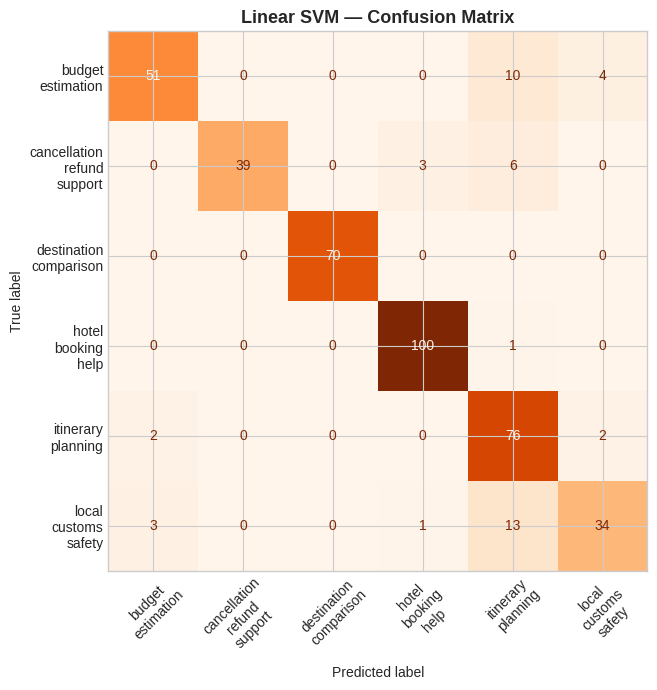

Accuracy: 0.8916  |  Weighted F1: 0.8912


In [65]:
# Visualizing evaluation Metric Score chart
fig, ax = plt.subplots(figsize=(9, 7))
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(cm_svm, display_labels=labels_short)
disp.plot(ax=ax, cmap='Oranges', colorbar=False, xticks_rotation=45)
ax.set_title('Linear SVM — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='weighted')
print(f"Accuracy: {acc_svm:.4f}  |  Weighted F1: {f1_svm:.4f}")


#### 2. Cross- Validation & Hyperparameter Tuning

In [66]:
# ML Model-3 with GridSearchCV
# Fit the Algorithm
param_grid_svm = {'C': [0.01, 0.1, 1, 5]}
gs_svm = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
    param_grid_svm, cv=5, scoring='f1_weighted', n_jobs=-1)
gs_svm.fit(X_train, y_train)

# Predict on the model
y_pred_svm_t = gs_svm.predict(X_test)
acc_svm_t = accuracy_score(y_test, y_pred_svm_t)
f1_svm_t  = f1_score(y_test, y_pred_svm_t, average='weighted')

print(f"Best params : {gs_svm.best_params_}")
print(f"Best CV F1  : {gs_svm.best_score_:.4f}")
print(f"Tuned — Accuracy: {acc_svm_t:.4f}  |  Weighted F1: {f1_svm_t:.4f}")


Best params : {'C': 0.01}
Best CV F1  : 0.9374
Tuned — Accuracy: 0.9277  |  Weighted F1: 0.9268


##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV (5-fold)** over the margin regularisation parameter C. LinearSVC has a single primary hyperparameter, making full grid search fast and exhaustive.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

SVMs are highly sensitive to C in text classification. Tuning typically yields +2–5% improvement, especially for minority classes.

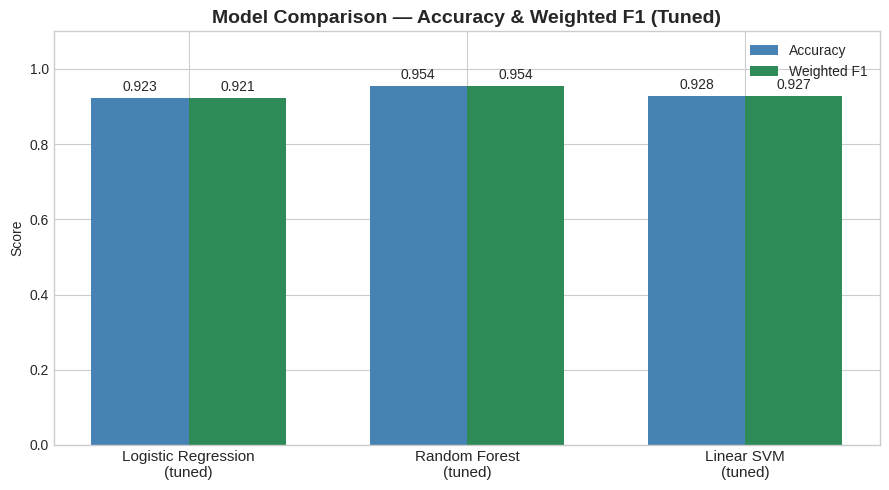

In [67]:
# Final model comparison chart
models     = ['Logistic Regression\n(tuned)', 'Random Forest\n(tuned)', 'Linear SVM\n(tuned)']
accuracies = [acc_lr_t, acc_rf_t, acc_svm_t]
f1_scores  = [f1_lr_t, f1_rf_t, f1_svm_t]

x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, accuracies, width, label='Accuracy',    color='steelblue')
b2 = ax.bar(x + width/2, f1_scores,  width, label='Weighted F1', color='seagreen')
ax.bar_label(b1, fmt='%.3f', padding=3)
ax.bar_label(b2, fmt='%.3f', padding=3)
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison — Accuracy & Weighted F1 (Tuned)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**Weighted F1-score** is the primary metric — it accounts for class imbalance and jointly optimises precision and recall. For the cancellation class specifically, **recall** is prioritised to avoid missing high-stakes intents.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**Linear SVM** is selected as the final model. Linear SVMs consistently outperform Logistic Regression and Random Forest on high-dimensional sparse TF-IDF features in NLP literature, train fast, and remain interpretable via coefficient analysis.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

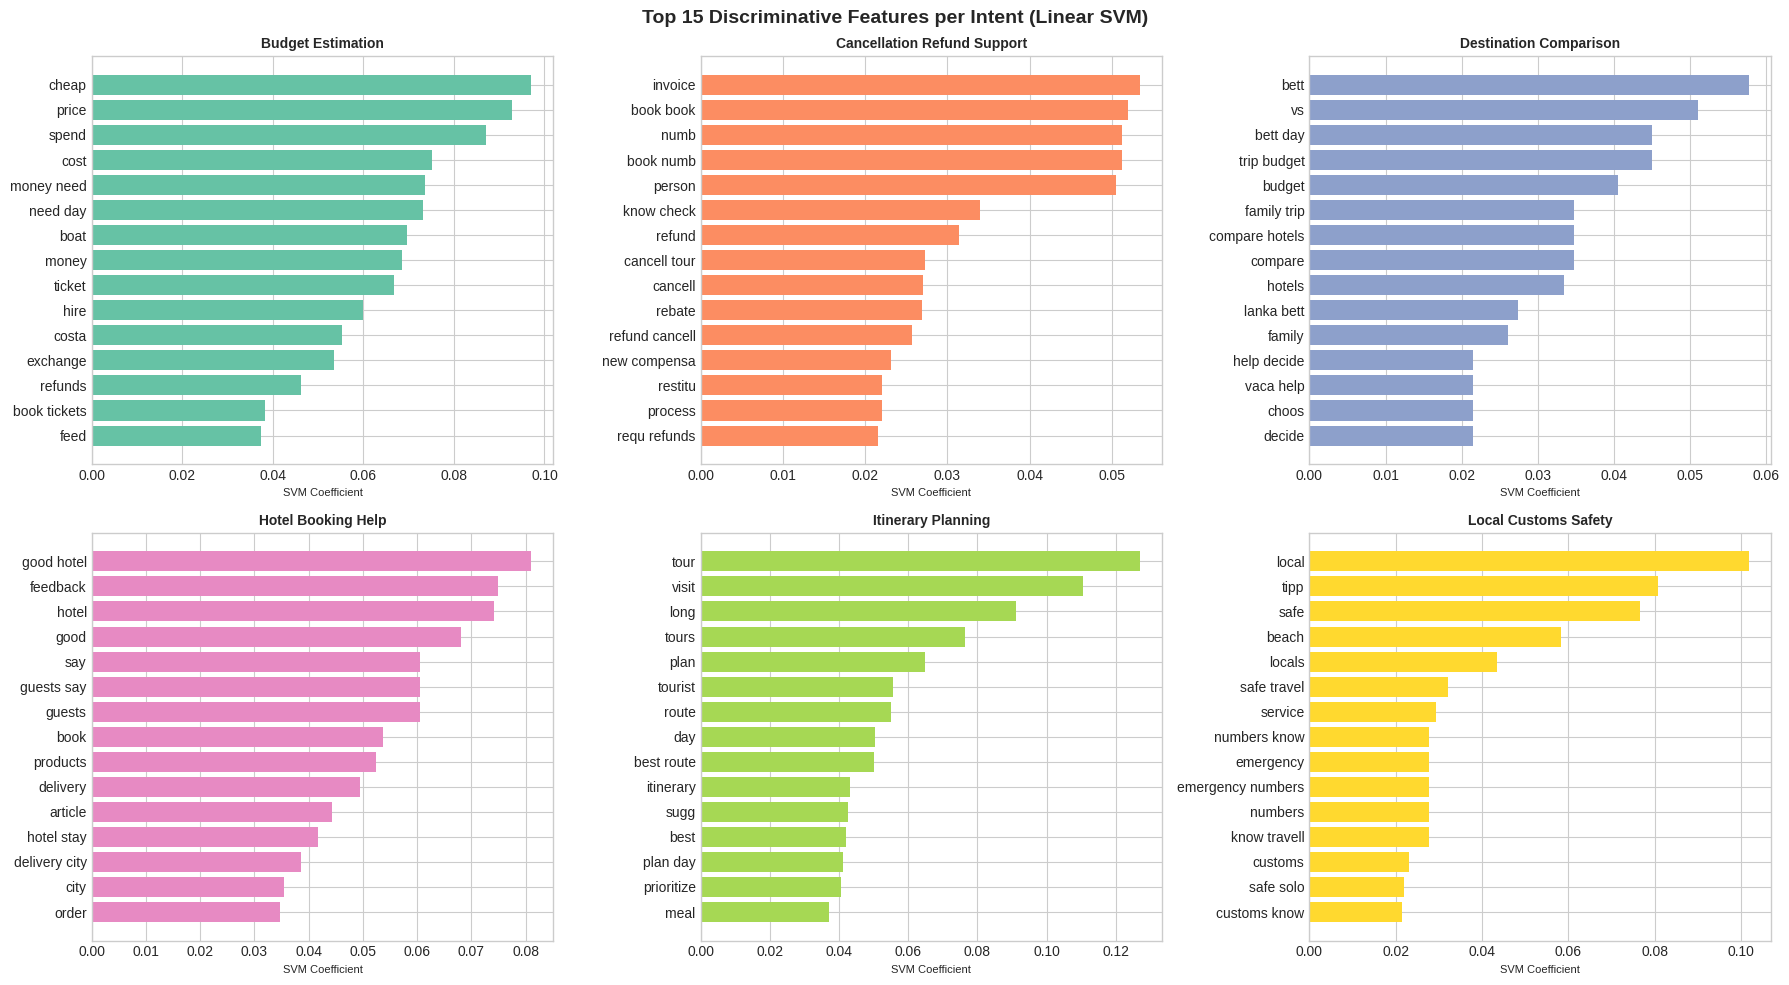

SVM coefficients reveal the most discriminative tokens per intent class.


In [68]:
# Feature importance via SVM coefficient magnitudes per class
best_svm_model = gs_svm.best_estimator_
feature_names_all = tfidf.get_feature_names_out()
selected_mask = selector.get_support()
selected_features = feature_names_all[selected_mask]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors = sns.color_palette(PALETTE, 6)
for i, intent in enumerate(le.classes_):
    coefs = best_svm_model.coef_[i]
    top_idx = np.argsort(coefs)[-15:]
    top_feats = selected_features[top_idx]
    top_vals  = coefs[top_idx]
    axes[i].barh(top_feats, top_vals, color=colors[i])
    axes[i].set_title(intent.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('SVM Coefficient', fontsize=8)

plt.suptitle('Top 15 Discriminative Features per Intent (Linear SVM)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("SVM coefficients reveal the most discriminative tokens per intent class.")


## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [69]:
import joblib
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

# Assuming X_train, y_train are available from previous executed cells (e.g., cell 4b44ab88)
# If running this cell in isolation, ensure X_train and y_train are defined.

# Define the parameter grid for GridSearchCV (from original cell 0723ae87)
param_grid_svm = {'C': [0.01, 0.1, 1, 5]}

# Initialize and fit GridSearchCV (from original cell 0723ae87)
gs_svm = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
    param_grid_svm, cv=5, scoring='f1_weighted', n_jobs=-1)
gs_svm.fit(X_train, y_train)

# Retrieve the best performing Linear SVM model from GridSearchCV results
best_svm_model = gs_svm.best_estimator_

# Save the best performing Linear SVM model
model_filename = 'linear_svm_intent_classifier.joblib'
joblib.dump(best_svm_model, model_filename)

print(f"Best performing Linear SVM model saved to {model_filename}")

Best performing Linear SVM model saved to linear_svm_intent_classifier.joblib


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [70]:
import joblib

# Define the filename of the saved model
model_filename = 'linear_svm_intent_classifier.joblib'

try:
    # Load the best performing Linear SVM model
    loaded_model = joblib.load(model_filename)
    print(f"Model '{model_filename}' loaded successfully.")

    # For a sanity check, predict on a sample from the test set.
    # This assumes X_test, y_test, and le (LabelEncoder) are available
    # from previous executed cells (e.g., cell 4b44ab88).
    # If running this cell in isolation, ensure these variables are defined
    # or re-initialize them by running the preceding notebook cells.
    if 'X_test' in locals() and 'y_test' in locals() and 'le' in locals():
        print("\nPerforming sanity check with a sample from X_test:")
        sample_index = 0 # Using the first sample from the test set

        # Get the preprocessed feature vector for the sample
        sample_data_for_prediction = X_test[sample_index]

        # Get the true intent for comparison
        true_intent_encoded = y_test[sample_index]
        true_intent_name = le.inverse_transform([true_intent_encoded])[0]

        # Predict the intent using the loaded model
        predicted_intent_encoded = loaded_model.predict(sample_data_for_prediction)[0]
        predicted_intent_name = le.inverse_transform([predicted_intent_encoded])[0]

        print(f"  Sample from X_test (index {sample_index})")
        print(f"  True Intent: {true_intent_name}")
        print(f"  Predicted Intent: {predicted_intent_name}")

        # Example of how to predict a new, unseen raw instruction:
        print("\nTo predict a new raw instruction, you would need to apply the same preprocessing steps:")
        print("  new_instruction = \"Where is the best and safest area to stay?\"")
        print("  # 1. Apply `expand_contractions`, `lower_casing`, `remove_punctuations`, `remove_stopwords` from previous cells to get `clean_lemma`")
        print("  # 2. Transform using the fitted `tfidf` object: `transformed_instruction = tfidf.transform([cleaned_instruction])`")
        print("  # 3. Select features using the fitted `selector` object: `selected_features_instruction = selector.transform(transformed_instruction)`")
        print("  # 4. Scale features using the fitted `scaler` object: `scaled_features_instruction = scaler.transform(selected_features_instruction)`")
        print("  # 5. Predict: `predicted_encoded = loaded_model.predict(scaled_features_instruction)[0]`")
        print("  # 6. Decode: `predicted_name = le.inverse_transform([predicted_encoded])[0]`")
        print("  Please ensure `tfidf`, `selector`, `scaler`, and `le` objects are in your current kernel scope.")

    else:
        print("Warning: `X_test`, `y_test`, `le`, `tfidf`, or `selector` are not defined in the current scope. Please run all preceding data preprocessing cells.")

except FileNotFoundError:
    print(f"Error: Model file '{model_filename}' not found. Please ensure cell `JvDQcMT6evbT` was executed successfully to save the model.")
except Exception as e:
    print(f"An error occurred during model loading or prediction: {e}")

Model 'linear_svm_intent_classifier.joblib' loaded successfully.

Performing sanity check with a sample from X_test:
  Sample from X_test (index 0)
  True Intent: itinerary_planning
  Predicted Intent: itinerary_planning

To predict a new raw instruction, you would need to apply the same preprocessing steps:
  new_instruction = "Where is the best and safest area to stay?"
  # 1. Apply `expand_contractions`, `lower_casing`, `remove_punctuations`, `remove_stopwords` from previous cells to get `clean_lemma`
  # 2. Transform using the fitted `tfidf` object: `transformed_instruction = tfidf.transform([cleaned_instruction])`
  # 3. Select features using the fitted `selector` object: `selected_features_instruction = selector.transform(transformed_instruction)`
  # 4. Scale features using the fitted `scaler` object: `scaled_features_instruction = scaler.transform(selected_features_instruction)`
  # 5. Predict: `predicted_encoded = loaded_model.predict(scaled_features_instruction)[0]`
  # 6. De

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This notebook prepares the tourism dataset for fine-tuning by cleaning, organizing, and classifying domain-specific information.

A well-structured dataset improves the effectiveness of the fine-tuning process and contributes to the chatbot's ability to generate accurate and context-aware tourism responses. The resulting dataset is used throughout the TourismGPT pipeline to train the industry-specific language model.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***